In [1]:
import torch
import torch.nn as nn

import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision import models
import torch.nn.functional as F

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

# Residual Attention Conditional UNET MODEL


In [3]:
class ResBlock(nn.Module):

    """
    Initialize a residual block with two convolutions followed by batchnorm layers
    """
    def __init__(self, in_channels:int, out_channels:int, kernel_size: int = 3):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size, stride = 2,  padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size, padding=1)
        self.conv3 = nn.Conv2d(out_channels, out_channels, kernel_size, padding=1)
        self.batchnorm1 = nn.BatchNorm2d(out_channels)
        self.batchnorm2 = nn.BatchNorm2d(out_channels)

    def convblock(self, x):
        x = F.leaky_relu(self.batchnorm1(self.conv1(x)), negative_slope=0.01)
        x = F.leaky_relu(self.batchnorm2(self.conv2(x)), negative_slope=0.01)
        x = self.batchnorm2(self.conv3(x))
        return x
    
    def forward(self, x): 
        return self.conv1(x) + self.convblock(x)

In [4]:
class AttentionBlock(nn.Module):
    """Attention block with learnable parameters"""

    def __init__(self, F_g, F_l, n_coefficients):
        """
        :param F_g: number of feature maps (channels) in previous layer
        :param F_l: number of feature maps in corresponding encoder layer, transferred via skip connection
        :param n_coefficients: number of learnable multi-dimensional attention coefficients
        """
        super(AttentionBlock, self).__init__()

        self.W_gate = nn.Sequential(
            nn.Conv2d(F_g, n_coefficients, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(n_coefficients)
        )

        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, n_coefficients, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(n_coefficients)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(n_coefficients, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, gate, skip_connection):
        """
        :param gate: gating signal from previous layer
        :param skip_connection: activation from corresponding encoder layer
        :return: output activations
        """
        g1 = self.W_gate(gate)
        x1 = self.W_x(skip_connection)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        out = skip_connection * psi
        return out

In [5]:
class UpConv(nn.Module):
    
    """
    Initialize a Upscale cum Conv layer that takes skip connections also as parameter
    """
    
    def __init__(self, in_channels:int , out_channels:int , kernel_size:int = 3):
        super(UpConv, self).__init__()
        self.conv1 = nn.Sequential(
                    nn.Conv2d(in_channels, in_channels, kernel_size, padding = 1),
                    nn.BatchNorm2d(in_channels),
                    nn.LeakyReLU(negative_slope=0.01),
                    nn.Conv2d(in_channels, out_channels, kernel_size, padding = 1),
                    nn.BatchNorm2d(out_channels)
        )
                
                                
        
        self.up = nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, 2, stride = 2),
            nn.BatchNorm2d(out_channels),
            nn.Conv2d(out_channels, out_channels, kernel_size, padding = 1),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(negative_slope=0.01)
        )
        
        
    def forward(self, x, skip, Attention):
        #print(x.shape)
        out = self.up(x)   
        #print(out.shape)
        skip = Attention(gate = out, skip_connection = skip)
        cat = torch.cat((out, skip), dim = 1)
        #print(cat.shape)
        out = self.conv1(cat)
        #print(out.shape)
        out = out + skip
        out = F.leaky_relu(out, negative_slope=0.01)
        return out

In [6]:
class RAC_UNET(nn.Module):

    def __init__(self, in_channels, out_channels, n_classes:int):
        super(RAC_UNET, self).__init__()
        
        self.EmbedLayer = nn.Embedding(n_classes, in_channels + 1)
        self.upfeature = nn.Conv2d(7, 32, kernel_size = 3, padding = 1)
        
        self.contract0 = nn.Sequential(
                nn.Conv2d(32, 64, kernel_size = 3, padding = 1),
                nn.BatchNorm2d(64),
                nn.LeakyReLU(negative_slope=0.01)
        )
        
        self.contract1 = ResBlock(64, 128)
        self.contract2 = ResBlock(128, 256)
        self.contract3 = ResBlock(256, 512)
        self.contract4 = ResBlock(512, 1024)
        
        self.bridge = nn.Conv2d(1024, 1024, kernel_size = 3, padding = 1)
        
        self.expand4 = UpConv(1024, 512)
        self.expand3 = UpConv(512, 256)
        self.expand2 = UpConv(256, 128)
        self.expand1 = UpConv(128, 64)
        
        self.Att4 = AttentionBlock(F_g=512, F_l=512, n_coefficients=256)
        self.Att3 = AttentionBlock(F_g=256, F_l=256, n_coefficients=128)
        self.Att2 = AttentionBlock(F_g=128, F_l=128, n_coefficients=64)
        self.Att1 = AttentionBlock(F_g=64, F_l=64, n_coefficients=32)
        
        self.downfeature = nn.Conv2d(64, 3, kernel_size = 3, padding = 1)
        
        
    def forward(self, x:torch.tensor, label:torch.tensor):
        """
        x - Input image tensor
        label - emotion label : tensor of shape [1]
        """
        
        label_embed = self.EmbedLayer(label).squeeze() #[8, 1, 4]
        label_embed = label_embed.unsqueeze(-1).unsqueeze(-1) #[8, 4, 1, 1]
        label_embed = label_embed.repeat(1, 1, 128, 128) #[1, 4, 128, 128]
       
        x = torch.cat((x, label_embed), dim = 1) #[1, 7, 128, 128]
        x = self.upfeature(x) #[1, 64, 128, 128]
        
        c0 = self.contract0(x) #[1, 64, 128, 128]
        c1 = self.contract1(c0) #[1, 128, 64, 64]
        c2 = self.contract2(c1) #[1, 256, 32, 32]
        c3 = self.contract3(c2) #[1, 512, 16, 16]
        c4 = self.contract4(c3) #[1, 1024, 8, 8]
                  
        e4 = self.bridge(c4) #[1, 1024, 8, 8]
  #      print("e4",e4.shape)  
        
        e4 = self.expand4(e4, c3, self.Att4) #[1, 512, 16, 16]
        e3 = self.expand3(e4, c2, self.Att3) #[1, 256, 32, 32]
        e2 = self.expand2(e3, c1, self.Att2) #[1, 128, 64, 64]
        e1 = self.expand1(e2, c0, self.Att1) #[1, 64, 128, 128]

        out = self.downfeature(e1)
#      print("c0", c0.shape)
#      print("c1",c1.shape)
#      print("c2",c2.shape)
#      print("c3",c3.shape)
#      print("c4",c4.shape)
#      print("e4",e4.shape)
#      print("e3",e3.shape)
#      print("e2",e2.shape) 
#      print("e1",e1.shape)
        return out

In [7]:
RacModel = RAC_UNET(3,3,7).to(device)

In [8]:
tensor = torch.rand(8,3,128,128)
label = torch.rand(8).type(torch.LongTensor)
print(tensor.shape, label.shape)
RacModel(tensor.to(device), label.to(device)).shape

torch.Size([8, 3, 128, 128]) torch.Size([8])


torch.Size([8, 3, 128, 128])

# Load Data and Transforms

In [9]:
import requests
import zipfile
from pathlib import Path
from PIL import Image
import csv

In [10]:
RESIZE = 128
BATCH_SIZE = 8
ToImage = torchvision.transforms.ToPILImage()

im_transform = transforms.Compose([
    transforms.Resize(size = (RESIZE, RESIZE)),
    transforms.ToTensor()
])

In [11]:
emotions = [0,1,2,3,4,5,6]
trainlist = []
for i in emotions:
    train_masked_path = Path("/kaggle/input/raffect-rafdb-affectnet/RAFFECT/train/masked/" + str(i))
    train_unmasked_path = Path("/kaggle/input/raffect-rafdb-affectnet/RAFFECT/train/unmasked/" + str(i))
    print(train_masked_path)
    label = i
    masked_img = list(sorted(train_masked_path.glob("*.*")))
    unmasked_img = list(sorted(train_unmasked_path.glob("*.*")))
    for j in range(len(masked_img)):
        temp = (masked_img[j], unmasked_img[j], label)
        trainlist.append(temp)

/kaggle/input/raffect-rafdb-affectnet/RAFFECT/train/masked/0
/kaggle/input/raffect-rafdb-affectnet/RAFFECT/train/masked/1
/kaggle/input/raffect-rafdb-affectnet/RAFFECT/train/masked/2
/kaggle/input/raffect-rafdb-affectnet/RAFFECT/train/masked/3
/kaggle/input/raffect-rafdb-affectnet/RAFFECT/train/masked/4
/kaggle/input/raffect-rafdb-affectnet/RAFFECT/train/masked/5
/kaggle/input/raffect-rafdb-affectnet/RAFFECT/train/masked/6


In [12]:
emotions = [0,1,2,3,4,5,6]
testlist = []
for i in emotions:
    test_masked_path = Path("/kaggle/input/rafdb-emotion-sorted/RAFDB Emotion Sorted/test/masked/" + str(i))
    test_unmasked_path = Path("/kaggle/input/rafdb-emotion-sorted/RAFDB Emotion Sorted/test/unmasked/" + str(i))
    print(test_masked_path)
    label = i
    masked_img = list(sorted(test_masked_path.glob("*.*")))
    unmasked_img = list(sorted(test_unmasked_path.glob("*.*")))
    for j in range(len(masked_img)):
        temp = (masked_img[j], unmasked_img[j], label)
        testlist.append(temp)

/kaggle/input/rafdb-emotion-sorted/RAFDB Emotion Sorted/test/masked/0
/kaggle/input/rafdb-emotion-sorted/RAFDB Emotion Sorted/test/masked/1
/kaggle/input/rafdb-emotion-sorted/RAFDB Emotion Sorted/test/masked/2
/kaggle/input/rafdb-emotion-sorted/RAFDB Emotion Sorted/test/masked/3
/kaggle/input/rafdb-emotion-sorted/RAFDB Emotion Sorted/test/masked/4
/kaggle/input/rafdb-emotion-sorted/RAFDB Emotion Sorted/test/masked/5
/kaggle/input/rafdb-emotion-sorted/RAFDB Emotion Sorted/test/masked/6


In [13]:
len(testlist)

3067

In [14]:
class Dataset(torchvision.datasets.VisionDataset):
    def __init__(self, data):
        self.data = data
        
    def __getitem__(self, idx):
        masked = im_transform(Image.open(self.data[idx][0])).to(device)
        unmasked = im_transform(Image.open(self.data[idx][1])).to(device)
        emo_label = torch.tensor([self.data[idx][2]]).to(device)
#         print(self.data[idx])
        return masked, unmasked, emo_label
    
    def __len__(self):
        return len(self.data)

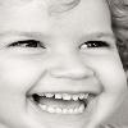

In [15]:
train_dataset = Dataset(trainlist)
test_dataset = Dataset(testlist)
train_dataloader = DataLoader(dataset = train_dataset, batch_size = BATCH_SIZE,
                              shuffle = True, drop_last = True)
test_dataloader = DataLoader(dataset = test_dataset, batch_size = BATCH_SIZE,
                             shuffle = True, drop_last = True)
ToImage(test_dataset[902][1])

In [16]:
print(next(iter(train_dataloader))[0].shape)

torch.Size([8, 3, 128, 128])


# SSIM_L1 Loss and Optimizer

In [17]:
#code from https://github.com/psyrocloud/MS-SSIM_L1_LOSS
class MS_SSIM_L1_LOSS(nn.Module):
    # Have to use cuda, otherwise the speed is too slow.
    def __init__(self, gaussian_sigmas=[0.5, 1.0, 2.0, 4.0, 8.0],
                 data_range = 1.0,
                 K=(0.01, 0.03),
                 alpha=0.025,
                 compensation=200.0,
                 cuda_dev=0,):
        super(MS_SSIM_L1_LOSS, self).__init__()
        self.DR = data_range
        self.C1 = (K[0] * data_range) ** 2
        self.C2 = (K[1] * data_range) ** 2
        self.pad = int(2 * gaussian_sigmas[-1])
        self.alpha = alpha
        self.compensation=compensation
        filter_size = int(4 * gaussian_sigmas[-1] + 1)
        g_masks = torch.zeros((3*len(gaussian_sigmas), 1, filter_size, filter_size))
        for idx, sigma in enumerate(gaussian_sigmas):
            # r0,g0,b0,r1,g1,b1,...,rM,gM,bM
            g_masks[3*idx+0, 0, :, :] = self._fspecial_gauss_2d(filter_size, sigma)
            g_masks[3*idx+1, 0, :, :] = self._fspecial_gauss_2d(filter_size, sigma)
            g_masks[3*idx+2, 0, :, :] = self._fspecial_gauss_2d(filter_size, sigma)
        self.g_masks = g_masks.cuda(cuda_dev)

    def _fspecial_gauss_1d(self, size, sigma):
        """Create 1-D gauss kernel
        Args:
            size (int): the size of gauss kernel
            sigma (float): sigma of normal distribution
        Returns:
            torch.Tensor: 1D kernel (size)
        """
        coords = torch.arange(size).to(dtype=torch.float)
        coords -= size // 2
        g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
        g /= g.sum()
        return g.reshape(-1)

    def _fspecial_gauss_2d(self, size, sigma):
        """Create 2-D gauss kernel
        Args:
            size (int): the size of gauss kernel
            sigma (float): sigma of normal distribution
        Returns:
            torch.Tensor: 2D kernel (size x size)
        """
        gaussian_vec = self._fspecial_gauss_1d(size, sigma)
        return torch.outer(gaussian_vec, gaussian_vec)

    def forward(self, x, y):
        b, c, h, w = x.shape
        mux = F.conv2d(x, self.g_masks, groups=3, padding=self.pad)
        muy = F.conv2d(y, self.g_masks, groups=3, padding=self.pad)

        mux2 = mux * mux
        muy2 = muy * muy
        muxy = mux * muy

        sigmax2 = F.conv2d(x * x, self.g_masks, groups=3, padding=self.pad) - mux2
        sigmay2 = F.conv2d(y * y, self.g_masks, groups=3, padding=self.pad) - muy2
        sigmaxy = F.conv2d(x * y, self.g_masks, groups=3, padding=self.pad) - muxy

        # l(j), cs(j) in MS-SSIM
        l  = (2 * muxy    + self.C1) / (mux2    + muy2    + self.C1)  # [B, 15, H, W]
        cs = (2 * sigmaxy + self.C2) / (sigmax2 + sigmay2 + self.C2)

        lM = l[:, -1, :, :] * l[:, -2, :, :] * l[:, -3, :, :]
        PIcs = cs.prod(dim=1)

        loss_ms_ssim = 1 - lM*PIcs  # [B, H, W]

        loss_l1 = F.l1_loss(x, y, reduction='none')  # [B, 3, H, W]
        # average l1 loss in 3 channels
        gaussian_l1 = F.conv2d(loss_l1, self.g_masks.narrow(dim=0, start=-3, length=3),
                               groups=3, padding=self.pad).mean(1)  # [B, H, W]

        loss_mix = self.alpha * loss_ms_ssim + (1 - self.alpha) * gaussian_l1 / self.DR
        loss_mix = self.compensation*loss_mix

        return loss_mix.mean()

# Train & Test Loop

In [18]:
from tqdm.auto import tqdm

In [19]:
def TrainStep(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader,
             loss_fn: torch.nn.Module, optimizer: torch.optim.Optimizer,
             device: torch.device = device):
    
    trainloss = 0
    for batch, (X, y, label) in enumerate(dataloader):
        model.train()   
        y_pred = model(X, label)
        
        loss = loss_fn(y_pred, y)
        trainloss += loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        print(f"BATCH: {batch} | loss: {loss}", end = '\r')
    trainloss /= BATCH_SIZE
    print(f"TrainLoss of Epoch: {trainloss}")
    return trainloss
    

In [20]:
def TestStep(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader,
            loss_fn: torch.nn.Module, device: torch.device = device):
    
    model.eval()
    testloss = 0
    with torch.inference_mode():
        for X,y,label in dataloader:
            testpred = model(X, label)
            loss = loss_fn(testpred, y)
            testloss += loss

        testloss /= BATCH_SIZE
        print(f"TestLoss for Epoch: {testloss}")
    return testloss

# Main Loop

In [21]:
LOSS_FN = MS_SSIM_L1_LOSS().to(device)
OPTIMIZER = torch.optim.Adam(params = RacModel.parameters(), lr = 0.0001)

In [22]:
prev_save = torch.load("/kaggle/input/rac-unet-new-and-upgraded/RAC-UNET_RAFFECT_ep122")
RacModel.load_state_dict(prev_save)

<All keys matched successfully>

In [23]:
import os
model_path = 'A-UNETDummy'
torch.save(RacModel.state_dict(), model_path) 

In [24]:
epochs = 15
best_loss = 1000000.0
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch + 125}-----------------")
    avg_loss = TrainStep(RacModel, train_dataloader, LOSS_FN, OPTIMIZER, device)
    TestStep(RacModel, test_dataloader, LOSS_FN, device)
    if avg_loss < best_loss:
        os.remove(model_path) 
        best_loss = avg_loss                 
        model_path = 'RAC-UNET_RAFFECT_ep{}'.format(epoch + 125)
        torch.save(RacModel.state_dict(), model_path)

  0%|          | 0/15 [00:00<?, ?it/s]

Epoch: 125-----------------
TrainLoss of Epoch: 1416.421142578125
TestLoss for Epoch: 473.30914306640625
Epoch: 126-----------------
TrainLoss of Epoch: 1426.58154296875
TestLoss for Epoch: 463.27496337890625
Epoch: 127-----------------
TrainLoss of Epoch: 1417.2802734375
TestLoss for Epoch: 478.5788269042969
Epoch: 128-----------------
TrainLoss of Epoch: 1400.09228515625
TestLoss for Epoch: 471.664794921875
Epoch: 129-----------------
TrainLoss of Epoch: 1403.0452880859375
TestLoss for Epoch: 474.0607604980469
Epoch: 130-----------------
TrainLoss of Epoch: 1399.6734619140625
TestLoss for Epoch: 499.075927734375
Epoch: 131-----------------
TrainLoss of Epoch: 1392.7967529296875
TestLoss for Epoch: 555.1292114257812
Epoch: 132-----------------
TrainLoss of Epoch: 1394.9984130859375
TestLoss for Epoch: 453.9767150878906
Epoch: 133-----------------
TrainLoss of Epoch: 1390.957763671875
TestLoss for Epoch: 465.78118896484375
Epoch: 134-----------------
TrainLoss of Epoch: 1390.3842773437

# Testing

In [25]:
ToImage = torchvision.transforms.ToPILImage()

from timeit import default_timer as timer
def print_train_timer(start: float,
                      end: float,
                      device: torch.device = None):
  total_time = end - start
  print(f"Time to compute: {total_time} on {device}")

from torchmetrics import PeakSignalNoiseRatio
psnr = PeakSignalNoiseRatio().to(device)

/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:98: UserWarning: unable to load libtensorflow_io_plugins.so: unable to open file: libtensorflow_io_plugins.so, from paths: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so']
caused by: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so: undefined symbol: _ZN3tsl6StatusC1EN10tensorflow5error4CodeESt17basic_string_viewIcSt11char_traitsIcEENS_14SourceLocationE']
  warnings.warn(f"unable to load libtensorflow_io_plugins.so: {e}")
/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:104: UserWarning: file system plugins are not loaded: unable to open file: libtensorflow_io.so, from paths: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io.so']
caused by: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io.so: undefined symbol: _ZTVN10tenso

In [26]:
MaskedImages, GTImages, label = next(iter(test_dataloader))

Time to compute: 0.006819219001044985 on cuda
Loss:  tensor(35.8466, device='cuda:0')
Emotion label:  tensor([6], device='cuda:0')
PSNR:  tensor(24.0794, device='cuda:0')


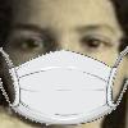

In [27]:
MaskedImages, GTImages, label = next(iter(test_dataloader))
idx = 1
Masked = ToImage(MaskedImages[idx])
UnMasked = ToImage(GTImages[idx])

pred_start = timer()
with torch.inference_mode():
    Pred_tensor = RacModel(MaskedImages.to(device), label.to(device))
pred_end = timer()
print_train_timer(pred_start, pred_end, device)

Prediction = ToImage(Pred_tensor[idx])
print("Loss: ", LOSS_FN(Pred_tensor[idx].unsqueeze(0), GTImages[0].unsqueeze(0)))
print("Emotion label: ", label[idx])
print("PSNR: ", psnr(Pred_tensor[idx], GTImages[idx]))
Masked

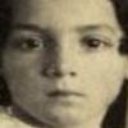

In [28]:
UnMasked

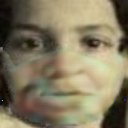

In [29]:
Prediction

# Compute Brisque etc

In [30]:
class VGGPerceptualLoss(torch.nn.Module):
    def __init__(self, resize=True):
        super(VGGPerceptualLoss, self).__init__()
        blocks = []
        blocks.append(torchvision.models.vgg16(pretrained=True).features[:4].eval())
        blocks.append(torchvision.models.vgg16(pretrained=True).features[4:9].eval())
        blocks.append(torchvision.models.vgg16(pretrained=True).features[9:16].eval())
        blocks.append(torchvision.models.vgg16(pretrained=True).features[16:23].eval())
        for bl in blocks:
            for p in bl.parameters():
                p.requires_grad = False
        self.blocks = torch.nn.ModuleList(blocks)
        self.transform = torch.nn.functional.interpolate
        self.resize = resize
        self.register_buffer("mean", torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer("std", torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def forward(self, input, target, feature_layers=[0, 1, 2, 3], style_layers=[]):
        if input.shape[1] != 3:
            input = input.repeat(1, 3, 1, 1)
            target = target.repeat(1, 3, 1, 1)
        input = (input-self.mean) / self.std
        target = (target-self.mean) / self.std
        if self.resize:
            input = self.transform(input, mode='bilinear', size=(224, 224), align_corners=False)
            target = self.transform(target, mode='bilinear', size=(224, 224), align_corners=False)
        loss = 0.0
        x = input
        y = target
        for i, block in enumerate(self.blocks):
            x = block(x)
            y = block(y)
            if i in feature_layers:
                loss += torch.nn.functional.l1_loss(x, y)
            if i in style_layers:
                act_x = x.reshape(x.shape[0], x.shape[1], -1)
                act_y = y.reshape(y.shape[0], y.shape[1], -1)
                gram_x = act_x @ act_x.permute(0, 2, 1)
                gram_y = act_y @ act_y.permute(0, 2, 1)
                loss += torch.nn.functional.l1_loss(gram_x, gram_y)
        return loss
    
perceptualloss = VGGPerceptualLoss().to(device)


!pip install piq
from piq import FID, brisque

def ComputeMetric(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader,
            metric: torch.nn.Module):
    metric_val = 0
    with torch.inference_mode():
        for batch, (masked, gt, labels) in enumerate(dataloader):
            batchloss = 0
            pred = model(masked, labels)
            batchloss += metric(pred, gt)
            metric_val += batchloss
            print(f"Batch: {batch} | BatchLoss: {batchloss}", end = "\r")
            
        metric_val = metric_val / (len(dataloader) * BATCH_SIZE)
    return metric_val

def NormalizeTensor(data):
    return (data - torch.min(data)) / (torch.max(data) - torch.min(data))

def ComputeBrisque(model, dataloader):
    brisque_score = 0.0
    with torch.inference_mode():
        for batch, (masked, gt, labels) in enumerate(dataloader):
            for i in range(BATCH_SIZE):
                pred = model(masked[i].unsqueeze(0), labels[i])
                pred = NormalizeTensor(pred)
                loss = brisque(pred)
                brisque_score += loss
                print(f"Batch: {batch} | BatchLoss: {loss}", end = "\r")
#                 print(pred.shape)
#                 print(brisque_score)
        brisque_score = brisque_score/(len(dataloader) * BATCH_SIZE)

/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:02<00:00, 248MB/s]


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.9/106.9 kB 3.3 MB/s eta 0:00:00


In [31]:
ComputeMetric(RacModel, test_dataloader, psnr)

tensor(2.8085, device='cuda:0')

In [32]:
ComputeMetric(RacModel, test_dataloader, LOSS_FN)

tensor(1.1913, device='cuda:0')

In [33]:
ComputeMetric(RacModel, test_dataloader, perceptualloss)

tensor(0.1424, device='cuda:0')

In [34]:
ComputeBrisque(RacModel, test_dataloader)

Downloading: "https://github.com/photosynthesis-team/piq/releases/download/v0.4.0/brisque_svm_weights.pt" to /root/.cache/torch/hub/checkpoints/brisque_svm_weights.pt
100%|██████████| 112k/112k [00:00<00:00, 4.88MB/s]


# Class Accuracy

In [35]:
import math
import torch.utils.model_zoo as model_zoo
import numpy as np
import itertools
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import os

In [36]:
__all__ = ['ResNet', 'resnet18', 'resnet34', 'resnet50', 'resnet101',
           'resnet152']


model_urls = {
    'resnet18': 'https://download.pytorch.org/models/resnet18-5c106cde.pth',
    'resnet34': 'https://download.pytorch.org/models/resnet34-333f7ec4.pth',
    'resnet50': 'https://download.pytorch.org/models/resnet50-19c8e357.pth',
    'resnet101': 'https://download.pytorch.org/models/resnet101-5d3b4d8f.pth',
    'resnet152': 'https://download.pytorch.org/models/resnet152-b121ed2d.pth',
}

def sigmoid(x):
    return 1 / (1 + math.exp(-x))

def norm_angle(angle):
    norm_angle = sigmoid(10 * (abs(angle) / 0.7853975 - 1))
    return norm_angle

def conv3x3(in_planes, out_planes, stride=1):
    "3x3 convolution with padding"
    return nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride,
                     padding=1, bias=False)


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = conv3x3(inplanes, planes, stride)
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU()
        self.conv2 = conv3x3(planes, planes)
        self.bn2 = nn.BatchNorm2d(planes)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        residual = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            residual = self.downsample(x)

        out += residual
        out = self.relu(out)

        return out


class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super(Bottleneck, self).__init__()
        self.conv1 = nn.Conv2d(inplanes, planes, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=stride,
                               padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.conv3 = nn.Conv2d(planes, planes * 4, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(planes * 4)
        self.relu = nn.ReLU()
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        residual = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            residual = self.downsample(x)

        out = out + residual
        out = self.relu(out)

        return out


class ResNet(nn.Module):

    def __init__(self, block, layers, num_classes=7, end2end=True):
        self.inplanes = 64
        self.end2end = end2end
        super(ResNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3,
                               bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        
        self.classifier =  nn.Linear(512,num_classes)
        
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, math.sqrt(2. / n))
            elif isinstance(m, nn.BatchNorm2d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.inplanes, planes * block.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes * block.expansion),
            )

        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample))
        self.inplanes = planes * block.expansion
        for i in range(1, blocks):
            layers.append(block(self.inplanes, planes))

        return nn.Sequential(*layers)

    def forward(self, x):
       
        bs = x.size(0)
        f = x

        f = self.conv1(f)
        f = self.bn1(f)
        f = self.relu(f)
        f = self.maxpool(f)
        
        f = self.layer1(f)
        
        f = self.layer2(f)
        
        f = self.layer3(f)
        
        
        f = self.layer4(f)
        
        f = self.avgpool(f)
        
        f = f.squeeze(3).squeeze(2)
        
        pred = self.classifier(f)
        
        return pred



def resnet18(pretrained=False, **kwargs):
    """Constructs a ResNet-18 model.
    Args:
        pretrained (bool): If True, returns a model pre-trained on ImageNet
    """
    model = ResNet(BasicBlock, [2, 2, 2, 2], **kwargs)
    if pretrained:

        pretrained_state_dict = model_zoo.load_url(model_urls['resnet18'])
        model_state_dict = model.state_dict()

        for key in pretrained_state_dict:
           if  ((key == 'fc.weight') | (key=='fc.bias')) :
               print(key) 
               pass
           else:
               #print(key)
               model_state_dict[key] = pretrained_state_dict[key]
                
        model.load_state_dict(model_state_dict)
        
    return model

def resModel(pretrained = False): #resnet18
    
    model = torch.nn.DataParallel(resnet18(end2end= False,  pretrained= True)).to(device)
    
    if pretrained:
       
       checkpoint = torch.load('/kaggle/input/resnet-fer-classifier-statedict/res18_naive.pth_MSceleb.tar')
       pretrained_state_dict = checkpoint['state_dict']
       model_state_dict = model.state_dict()
        
       for key in pretrained_state_dict:
           if  ((key == 'module.fc.weight') | (key=='module.fc.bias') | (key=='module.feature.weight') | (key=='module.feature.bias') ) :
               print(key) 
               pass
           else:
               #print(key)
               model_state_dict[key] = pretrained_state_dict[key]

       model.load_state_dict(model_state_dict, strict = False)
       print('Model loaded from Msceleb pretrained')
    else:
       print('No pretrained resent18 model built.')
    return model   



In [37]:
Classifier = resModel(pretrained = False).to(device)
save = torch.load("/kaggle/input/working-resnet-classifier/Classifier_ep98")
Classifier.load_state_dict(save)

Downloading: "https://download.pytorch.org/models/resnet18-5c106cde.pth" to /root/.cache/torch/hub/checkpoints/resnet18-5c106cde.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 198MB/s]


fc.weight
fc.bias
No pretrained resent18 model built.


<All keys matched successfully>

In [38]:
def test(model, RAC,dataloader):
    with torch.no_grad():
        for batch,(masked,gt,labels) in enumerate(dataloader):
            print(f"batch: {batch}", end = '\r')
            for i in range(BATCH_SIZE):
                images = RAC(masked[i].unsqueeze(0), labels[i].unsqueeze(0))
                logits1 = model(images)

                outputs1 = F.softmax(logits1, dim=1)
                avg_output = outputs1.data 
                _, avg_pred = torch.max(avg_output, 1)

                if batch == 0 and i == 0:
                  all_predicted = avg_pred
                  all_targets = labels[i]
                else:
                  all_predicted = torch.cat((all_predicted, avg_pred), 0)
                  all_targets = torch.cat((all_targets, labels[i]), 0)
    return all_predicted, all_targets

def plot_confusion_matrix(cm, classes,
                          normalize=True,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)
    plt.rcParams.update({'font.size': 18}) 
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=16)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")


    plt.ylabel('True label', fontsize=18)
    plt.xlabel('Predicted label', fontsize=18)
    plt.tight_layout()

In [39]:
pred, tar = test(Classifier, RacModel, test_dataloader)

In [40]:
len(pred), len(tar)

(3064, 3064)

In [41]:
n_correct_emo = 0
for i in range(3057):
    if(pred[i] == tar[i]):
        n_correct_emo += 1
        print(pred[i], n_correct_emo, end = '\r')

Normalized confusion matrix
[[0.01215805 0.06382979 0.01519757 0.1550152  0.12462006 0.03039514
  0.59878419]
 [0.02702703 0.10810811 0.18918919 0.12162162 0.12162162 0.05405405
  0.37837838]
 [0.04375    0.54375    0.         0.1625     0.1625     0.04375
  0.04375   ]
 [0.00337553 0.02700422 0.00421941 0.91561181 0.03459916 0.00421941
  0.01097046]
 [0.01890756 0.13445378 0.02310924 0.18277311 0.20588235 0.41386555
  0.0210084 ]
 [0.39375    0.225      0.025      0.15625    0.11875    0.03125
  0.05      ]
 [0.02205882 0.11029412 0.01029412 0.21029412 0.525      0.04264706
  0.07941176]]


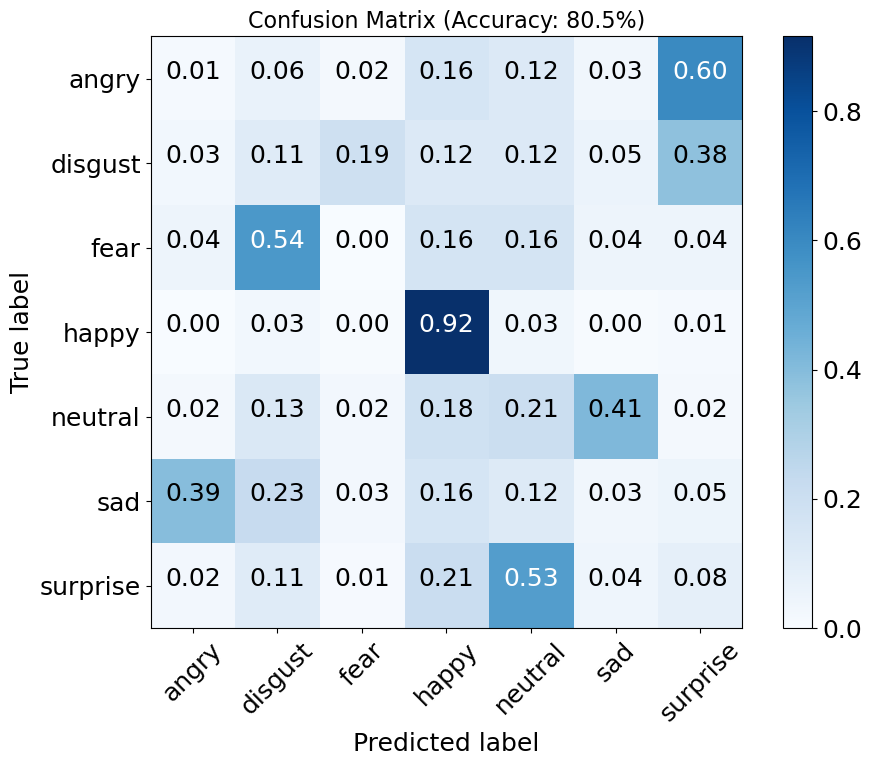

In [42]:
matrix = confusion_matrix(tar.data.cpu().numpy(), pred.cpu().numpy())

class_names = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]

plt.figure(figsize=(10, 8))
plot_confusion_matrix(matrix, classes = class_names, normalize=True,
              title= 'Confusion Matrix (Accuracy: 80.5%)' )

#plt.show()
plt.savefig(os.path.join( 'Confusion_Matrix_rafdb.png'))